# IronClad Task 1: Model Selection

This notebook addresses the first design question of the project: which embedding backbone (casia-webface or vggface2) should be selected for the IronClad face identification system? 

To ensure that any observed performance difference is attributable to the embedding model itself and not to search approximation, all evaluations use exact Brute Force retrieval through FAISS. 

The notebook evaluates both backbones under three native exact distance metrics (Euclidean, cosine similarity, and dot product) and reports clean Top-1, Top-3, and Top-5 accuracy, as well as average and worst-case Top-1 accuracy under controlled noise perturbations (Gaussian blur, resizing, and brightness changes). Mean Reciprocal Rank (MRR) is included as a complementary ranking-quality metric. 

The notebook includes a supplementary analysis under the Minkowski distance, which in our implementation is not a native FAISS metric but is computed through candidate retrieval followed by reranking, and is therefore treated separately from the primary exact comparison.

## Imports and settings

In [1]:
import sys, subprocess, importlib, os, types
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image, ImageFilter, ImageEnhance, UnidentifiedImageError
import torch

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

def _ensure(pkg_import_name: str, pip_name: str | None = None):
    pip_name = pip_name or pkg_import_name
    try:
        importlib.import_module(pkg_import_name)
        print(f"{pkg_import_name} already installed")
    except Exception:
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
        importlib.import_module(pkg_import_name)
        print(f"Installed {pkg_import_name}")

_ensure("facenet_pytorch", "facenet-pytorch")
_ensure("faiss", "faiss-cpu")
_ensure("tqdm", "tqdm")

# Compatibility shim for some older checkpoints
if "torch.utils.serialization" not in sys.modules:
    sys.modules["torch.utils.serialization"] = types.ModuleType("torch.utils.serialization")

from tqdm.auto import tqdm

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


facenet_pytorch already installed
faiss already installed
tqdm already installed
Torch: 2.2.2+cpu
CUDA available: False


In [2]:
# Notebook is assumed to run in BASE/analysis
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ironclad.modules.extraction.preprocessing import Preprocessing
from ironclad.modules.extraction.embedding import Embedding
from ironclad.modules.retrieval.index.bruteforce import FaissBruteForce
from ironclad.modules.retrieval.search import FaissSearch

print("Project root:", PROJECT_ROOT)


Project root: C:\Users\Usuario\Downloads\ironclad-hortner87-main(1)\ironclad-hortner87-main


In [3]:
# Fixed dataset location used throughout the project
STORAGE_ROOT = PROJECT_ROOT / "ironclad" / "storage"
GALLERY_DIR = STORAGE_ROOT / "gallery"
PROBE_DIR = STORAGE_ROOT / "probe"

print("Storage root:", STORAGE_ROOT)
print("Gallery dir :", GALLERY_DIR)
print("Probe dir   :", PROBE_DIR)

if not (GALLERY_DIR.exists() and PROBE_DIR.exists()):
    raise FileNotFoundError(
        f"Expected gallery/probe at:\n  {GALLERY_DIR}\n  {PROBE_DIR}\n"
        "But one or both directories do not exist."
    )

def list_images_by_identity(base_dir: Path):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    out = {}
    for ident_dir in sorted([p for p in base_dir.iterdir() if p.is_dir()]):
        imgs = []
        for p in ident_dir.rglob("*"):
            if not p.is_file():
                continue
            if p.suffix.lower() not in exts:
                continue
            # skip macOS AppleDouble / hidden files
            if p.name.startswith("._") or p.name.startswith("."):
                continue
            imgs.append(p)
        if imgs:
            out[ident_dir.name] = sorted(imgs)
    return out

gallery = list_images_by_identity(GALLERY_DIR)
probe = list_images_by_identity(PROBE_DIR)

overlap = sorted(set(gallery.keys()) & set(probe.keys()))
print("Identities in gallery:", len(gallery))
print("Identities in probe  :", len(probe))
print("Overlap identities   :", len(overlap))
print("Example overlap      :", overlap[:5])


Storage root: C:\Users\Usuario\Downloads\ironclad-hortner87-main(1)\ironclad-hortner87-main\ironclad\storage
Gallery dir : C:\Users\Usuario\Downloads\ironclad-hortner87-main(1)\ironclad-hortner87-main\ironclad\storage\gallery
Probe dir   : C:\Users\Usuario\Downloads\ironclad-hortner87-main(1)\ironclad-hortner87-main\ironclad\storage\probe
Identities in gallery: 1000
Identities in probe  : 999
Overlap identities   : 999
Example overlap      : ['Aaron_Sorkin', 'Abdel_Nasser_Assidi', 'Abdullah', 'Abdullah_Gul', 'Abdullah_al-Attiyah']


## Evaluation protocol

We follow a standard **closed-set identification** protocol.

1. Build a **Brute Force** index from **gallery** embeddings.
2. For each **probe** image:
   - compute its embedding,
   - search the index,
   - measure whether the correct identity appears in the top-k results.

Because Brute Force is exact, any performance difference in the primary analysis comes from:

- the **embedding model**
- the **similarity metric**
- the **noise condition**

not from approximate indexing error.


In [4]:
# Flatten image lists
gallery_paths, gallery_labels = [], []
for ident in overlap:
    for p in gallery[ident]:
        gallery_paths.append(p)
        gallery_labels.append(ident)

probe_paths, probe_labels = [], []
for ident in overlap:
    for p in probe[ident]:
        probe_paths.append(p)
        probe_labels.append(ident)

print("Gallery images:", len(gallery_paths))
print("Probe images  :", len(probe_paths))


Gallery images: 2261
Probe images  : 999


In [5]:
preproc = Preprocessing(image_size=160)
CACHE_DIR = Path.cwd() / "cache_embeddings_task1_enhanced"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def pil_load_rgb(path: Path) -> Image.Image | None:
    try:
        return Image.open(path).convert("RGB")
    except (UnidentifiedImageError, OSError):
        return None

def apply_noise(img: Image.Image, noise_type: str, level: float) -> Image.Image:
    if noise_type == "none":
        return img
    if noise_type == "gaussian_blur":
        return img.filter(ImageFilter.GaussianBlur(radius=float(level)))
    if noise_type == "resize":
        scale = float(level)
        w, h = img.size
        w2, h2 = max(1, int(w * scale)), max(1, int(h * scale))
        img_small = img.resize((w2, h2), resample=Image.BILINEAR)
        return img_small.resize((w, h), resample=Image.BILINEAR)
    if noise_type == "brightness":
        return ImageEnhance.Brightness(img).enhance(float(level))
    raise ValueError(f"Unknown noise_type: {noise_type}")

def _cache_path(model_name: str, split: str, noise_type: str, noise_level: float):
    safe = f"{model_name}_{split}_{noise_type}_{str(noise_level).replace('.', 'p')}.npz"
    return CACHE_DIR / safe

def compute_embeddings(model_name: str, image_paths, labels, split: str,
                       noise_type: str = "none", noise_level: float = 0.0):
    """Compute (and cache) embeddings for a list of image paths under a given noise condition."""
    path = _cache_path(model_name, split, noise_type, noise_level)
    if path.exists():
        z = np.load(path, allow_pickle=True)
        return z["X"].astype(np.float32), z["labels"].tolist(), [Path(p) for p in z["paths"].tolist()]

    model = Embedding(pretrained=model_name, device=DEVICE)
    vecs, kept_labels, kept_paths = [], [], []

    for p, lab in tqdm(list(zip(image_paths, labels)), desc=f"Embedding {split} | {model_name} | {noise_type}={noise_level}"):
        img = pil_load_rgb(p)
        if img is None:
            continue
        img = apply_noise(img, noise_type, noise_level)
        tens = preproc.process(img)
        vec = model.encode(tens).astype(np.float32)
        vecs.append(vec)
        kept_labels.append(lab)
        kept_paths.append(str(p))

    X = np.vstack([v.reshape(1, -1) for v in vecs]).astype(np.float32)
    np.savez(path, X=X, labels=np.array(kept_labels, dtype=object), paths=np.array(kept_paths, dtype=object))
    return X, kept_labels, [Path(p) for p in kept_paths]


## Metrics and noise settings

Primary exact metrics:
- `euclidean`
- `cosine`
- `dot_product`

Noise settings:
- Gaussian blur radii: 1, 2, 3
- Resize scales: 0.75, 0.50, 0.35
- Brightness factors: 0.6, 0.8, 1.2, 1.4


In [6]:
PRIMARY_METRICS = ["euclidean", "cosine", "dot_product"]

# Minkowski Kept separate because it is not a native exact FAISS metric in this implementation.
INCLUDE_MINKOWSKI_SUPPLEMENT = False
MINKOWSKI_P = 3

NOISE_PLAN = [
    ("gaussian_blur", 1.0),
    ("gaussian_blur", 2.0),
    ("gaussian_blur", 3.0),
    ("resize", 0.75),
    ("resize", 0.50),
    ("resize", 0.35),
    ("brightness", 0.60),
    ("brightness", 0.80),
    ("brightness", 1.20),
    ("brightness", 1.40),
]

MODEL_NAMES = ["casia-webface", "vggface2"]
K_VALUES = (1, 3, 5)


In [7]:
# Precompute embeddings once per model and noise condition
# Important: embeddings depend on the MODEL and NOISE, but not on the retrieval metric
embedding_store = {}

for model_name in MODEL_NAMES:
    print(f"\n=== Precomputing embeddings for {model_name} ===")
    gal_X, gal_y, gal_p = compute_embeddings(model_name, gallery_paths, gallery_labels, split="gallery_clean",
                                             noise_type="none", noise_level=0.0)
    prb_X_clean, prb_y_clean, prb_p_clean = compute_embeddings(model_name, probe_paths, probe_labels, split="probe_clean",
                                                               noise_type="none", noise_level=0.0)
    embedding_store[(model_name, "gallery", "none", 0.0)] = (gal_X, gal_y, gal_p)
    embedding_store[(model_name, "probe", "none", 0.0)] = (prb_X_clean, prb_y_clean, prb_p_clean)

    for noise_type, noise_level in NOISE_PLAN:
        prb_X, prb_y, prb_p = compute_embeddings(model_name, probe_paths, probe_labels,
                                                 split="probe_noisy",
                                                 noise_type=noise_type,
                                                 noise_level=noise_level)
        embedding_store[(model_name, "probe", noise_type, noise_level)] = (prb_X, prb_y, prb_p)

print("Embedding cache ready.")



=== Precomputing embeddings for casia-webface ===

=== Precomputing embeddings for vggface2 ===
Embedding cache ready.


In [8]:
def evaluate_condition(model_name: str, metric: str, noise_type: str, noise_level: float,
                       k_values=(1, 3, 5), minkowski_p: int = 3) -> pd.DataFrame:
    """Evaluate one (model, metric, noise condition) setting."""
    gal_X, gal_y, _ = embedding_store[(model_name, "gallery", "none", 0.0)]
    prb_X, prb_y, _ = embedding_store[(model_name, "probe", noise_type, noise_level)]

    bf = FaissBruteForce(dim=gal_X.shape[1], metric="euclidean" if metric == "minkowski" else metric)
    bf.add_embeddings(gal_X, gal_y)
    searcher = FaissSearch(bf, metric=metric, p=minkowski_p)

    rows = []
    for k in k_values:
        correct = 0
        for qi in range(prb_X.shape[0]):
            _, _, meta = searcher.search(prb_X[qi], k=k)
            if prb_y[qi] in meta:
                correct += 1
        rows.append({
            "model": model_name,
            "metric": metric,
            "noise_type": noise_type,
            "noise_level": noise_level,
            "k": k,
            "topk_accuracy": correct / prb_X.shape[0] if prb_X.shape[0] else np.nan,
            "n_probe": prb_X.shape[0],
        })
    return pd.DataFrame(rows)


In [9]:
# Main exact analysis across models and metrics
all_rows = []

for metric in PRIMARY_METRICS:
    print(f"\n==============================")
    print(f"Running primary metric: {metric}")
    print(f"==============================")

    # Clean
    for model_name in MODEL_NAMES:
        all_rows.append(evaluate_condition(model_name, metric, "none", 0.0, k_values=K_VALUES))

    # Noisy (Top-1 only, like the original notebook)
    for noise_type, noise_level in NOISE_PLAN:
        for model_name in MODEL_NAMES:
            all_rows.append(evaluate_condition(model_name, metric, noise_type, noise_level, k_values=(1,)))

results_df = pd.concat(all_rows, ignore_index=True)
display(results_df)



Running primary metric: euclidean

Running primary metric: cosine

Running primary metric: dot_product


,model,metric,noise_type,noise_level,k,topk_accuracy,n_probe
0,casia-webface,euclidean,none,0.00,1,0.093093,999
1,casia-webface,euclidean,none,0.00,3,0.137137,999
2,casia-webface,euclidean,none,0.00,5,0.163163,999
3,vggface2,euclidean,none,0.00,1,0.506507,999
4,vggface2,euclidean,none,0.00,3,0.619620,999
5,vggface2,euclidean,none,0.00,5,0.664665,999
6,casia-webface,euclidean,gaussian_blur,1.00,1,0.092092,999
7,vggface2,euclidean,gaussian_blur,1.00,1,0.503504,999
8,casia-webface,euclidean,gaussian_blur,2.00,1,0.059059,999
9,vggface2,euclidean,gaussian_blur,2.00,1,0.445445,999


## Clean performance: Top-1 / Top-3 / Top-5

This reproduces the original model-selection logic, but now **for each retrieval metric**.


In [10]:
clean_df = results_df[results_df["noise_type"] == "none"].copy()
clean_summary = clean_df.pivot_table(
    index=["metric", "model"],
    columns="k",
    values="topk_accuracy",
    aggfunc="mean"
).reset_index().rename(columns={1: "top1", 3: "top3", 5: "top5"})

clean_summary = clean_summary.sort_values(["metric", "top1"], ascending=[True, False])
clean_summary


k,metric,model,top1,top3,top5
1,cosine,vggface2,0.506507,0.619620,0.664665
0,cosine,casia-webface,0.093093,0.137137,0.163163
3,dot_product,vggface2,0.506507,0.619620,0.664665
2,dot_product,casia-webface,0.093093,0.137137,0.163163
5,euclidean,vggface2,0.506507,0.619620,0.664665
4,euclidean,casia-webface,0.093093,0.137137,0.163163


## Noisy robustness summary

For each `(metric, model)` pair we compute:

- **average noisy Top-1**
- **worst-case noisy Top-1**

This is the strengthened version of the original robustness summary.


In [11]:
top1_all = results_df[results_df["k"] == 1].copy()

clean_top1 = top1_all[top1_all["noise_type"] == "none"][["metric", "model", "topk_accuracy"]].rename(
    columns={"topk_accuracy": "clean_top1"}
)

noisy_top1 = top1_all[top1_all["noise_type"] != "none"].copy()
avg_noisy = noisy_top1.groupby(["metric", "model"], as_index=False)["topk_accuracy"].mean().rename(
    columns={"topk_accuracy": "avg_noisy_top1"}
)
worst_noisy = noisy_top1.groupby(["metric", "model"], as_index=False)["topk_accuracy"].min().rename(
    columns={"topk_accuracy": "worst_noisy_top1"}
)

summary_df = clean_top1.merge(avg_noisy, on=["metric", "model"]).merge(worst_noisy, on=["metric", "model"])
summary_df = summary_df.sort_values(["metric", "clean_top1", "avg_noisy_top1", "worst_noisy_top1"],
                                    ascending=[True, False, False, False])
summary_df


,metric,model,clean_top1,avg_noisy_top1,worst_noisy_top1
3,cosine,vggface2,0.506507,0.399900,0.162162
2,cosine,casia-webface,0.093093,0.066967,0.029029
5,dot_product,vggface2,0.506507,0.399900,0.162162
4,dot_product,casia-webface,0.093093,0.066967,0.029029
1,euclidean,vggface2,0.506507,0.399900,0.162162
0,euclidean,casia-webface,0.093093,0.066967,0.029029


## Mean Reciprocal Rank (MRR)

We add **MRR** as a complementary ranking metric. For each probe, MRR rewards placing the first correct identity as early as possible in the ranked retrieval list, and summarizes this as the mean reciprocal rank across probes.

In [12]:

def evaluate_mrr_condition(model_name: str, metric: str, noise_type: str, noise_level: float,
                           minkowski_p: int = 3) -> pd.DataFrame:
    """Compute mean reciprocal rank for one (model, metric, noise condition) setting."""
    gal_X, gal_y, _ = embedding_store[(model_name, "gallery", "none", 0.0)]
    prb_X, prb_y, _ = embedding_store[(model_name, "probe", noise_type, noise_level)]

    bf = FaissBruteForce(dim=gal_X.shape[1], metric="euclidean" if metric == "minkowski" else metric)
    bf.add_embeddings(gal_X, gal_y)
    searcher = FaissSearch(bf, metric=metric, p=minkowski_p)

    reciprocal_ranks = []
    full_k = len(gal_y)
    for qi in range(prb_X.shape[0]):
        _, _, meta = searcher.search(prb_X[qi], k=full_k)
        rank = 0
        for idx, pred in enumerate(meta, start=1):
            if pred == prb_y[qi]:
                rank = idx
                break
        reciprocal_ranks.append(0.0 if rank == 0 else 1.0 / rank)

    return pd.DataFrame([{
        "model": model_name,
        "metric": metric,
        "noise_type": noise_type,
        "noise_level": noise_level,
        "mrr": float(np.mean(reciprocal_ranks)) if reciprocal_ranks else np.nan,
        "n_probe": prb_X.shape[0],
    }])

mrr_rows = []
for metric in PRIMARY_METRICS:
    for model_name in MODEL_NAMES:
        mrr_rows.append(evaluate_mrr_condition(model_name, metric, "none", 0.0))
    for noise_type, noise_level in NOISE_PLAN:
        for model_name in MODEL_NAMES:
            mrr_rows.append(evaluate_mrr_condition(model_name, metric, noise_type, noise_level))

mrr_df = pd.concat(mrr_rows, ignore_index=True)

clean_mrr = (
    mrr_df[mrr_df["noise_type"] == "none"][["metric", "model", "mrr"]]
    .rename(columns={"mrr": "clean_mrr"})
)

noisy_mrr = mrr_df[mrr_df["noise_type"] != "none"].copy()
avg_noisy_mrr = (
    noisy_mrr.groupby(["metric", "model"], as_index=False)["mrr"]
    .mean()
    .rename(columns={"mrr": "avg_noisy_mrr"})
)
worst_noisy_mrr = (
    noisy_mrr.groupby(["metric", "model"], as_index=False)["mrr"]
    .min()
    .rename(columns={"mrr": "worst_noisy_mrr"})
)

summary_df = (
    summary_df
    .merge(clean_mrr, on=["metric", "model"], how="left")
    .merge(avg_noisy_mrr, on=["metric", "model"], how="left")
    .merge(worst_noisy_mrr, on=["metric", "model"], how="left")
    .sort_values(
        ["metric", "clean_top1", "avg_noisy_top1", "worst_noisy_top1", "clean_mrr"],
        ascending=[True, False, False, False, False]
    )
    .reset_index(drop=True)
)

summary_df


,metric,model,clean_top1,avg_noisy_top1,worst_noisy_top1,clean_mrr,avg_noisy_mrr,worst_noisy_mrr
0,cosine,vggface2,0.506507,0.399900,0.162162,0.579554,0.475136,0.223738
1,cosine,casia-webface,0.093093,0.066967,0.029029,0.133991,0.103487,0.058432
2,dot_product,vggface2,0.506507,0.399900,0.162162,0.579554,0.475136,0.223738
3,dot_product,casia-webface,0.093093,0.066967,0.029029,0.133991,0.103487,0.058432
4,euclidean,vggface2,0.506507,0.399900,0.162162,0.579554,0.475136,0.223738
5,euclidean,casia-webface,0.093093,0.066967,0.029029,0.133991,0.103487,0.058432


## Does the winner change across metrics?

For each metric, we rank the two models using the same rule:

1. clean Top-1
2. average noisy Top-1
3. worst-case noisy Top-1

This directly answers whether the model winner is stable or metric-dependent.


In [13]:

winner_rows = []
for metric in PRIMARY_METRICS:
    sub = summary_df[summary_df["metric"] == metric].sort_values(
        ["clean_top1", "avg_noisy_top1", "worst_noisy_top1", "clean_mrr"],
        ascending=False
    )
    winner_rows.append({
        "metric": metric,
        "winner": sub.iloc[0]["model"],
        "runner_up": sub.iloc[1]["model"] if len(sub) > 1 else None,
        "winner_clean_top1": float(sub.iloc[0]["clean_top1"]),
        "winner_avg_noisy_top1": float(sub.iloc[0]["avg_noisy_top1"]),
        "winner_worst_noisy_top1": float(sub.iloc[0]["worst_noisy_top1"]),
        "winner_clean_mrr": float(sub.iloc[0]["clean_mrr"]),
        "winner_avg_noisy_mrr": float(sub.iloc[0]["avg_noisy_mrr"]),
        "winner_worst_noisy_mrr": float(sub.iloc[0]["worst_noisy_mrr"]),
    })

winner_df = pd.DataFrame(winner_rows)
winner_df


,metric,winner,runner_up,winner_clean_top1,winner_avg_noisy_top1,winner_worst_noisy_top1,winner_clean_mrr,winner_avg_noisy_mrr,winner_worst_noisy_mrr
0,euclidean,vggface2,casia-webface,0.506507,0.3999,0.162162,0.579554,0.475136,0.223738
1,cosine,vggface2,casia-webface,0.506507,0.3999,0.162162,0.579554,0.475136,0.223738
2,dot_product,vggface2,casia-webface,0.506507,0.3999,0.162162,0.579554,0.475136,0.223738


In [14]:

# Decision table
decision_table = clean_summary.merge(summary_df, on=["metric", "model"])
decision_table = decision_table.sort_values(
    ["metric", "top1", "avg_noisy_top1", "clean_mrr"],
    ascending=[True, False, False, False]
).reset_index(drop=True)
decision_table


,metric,model,top1,top3,top5,clean_top1,avg_noisy_top1,worst_noisy_top1,clean_mrr,avg_noisy_mrr,worst_noisy_mrr
0,cosine,vggface2,0.506507,0.619620,0.664665,0.506507,0.399900,0.162162,0.579554,0.475136,0.223738
1,cosine,casia-webface,0.093093,0.137137,0.163163,0.093093,0.066967,0.029029,0.133991,0.103487,0.058432
2,dot_product,vggface2,0.506507,0.619620,0.664665,0.506507,0.399900,0.162162,0.579554,0.475136,0.223738
3,dot_product,casia-webface,0.093093,0.137137,0.163163,0.093093,0.066967,0.029029,0.133991,0.103487,0.058432
4,euclidean,vggface2,0.506507,0.619620,0.664665,0.506507,0.399900,0.162162,0.579554,0.475136,0.223738
5,euclidean,casia-webface,0.093093,0.137137,0.163163,0.093093,0.066967,0.029029,0.133991,0.103487,0.058432


## Visualizations

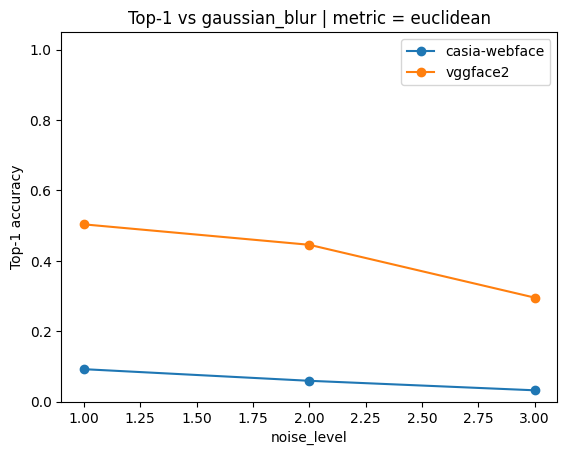

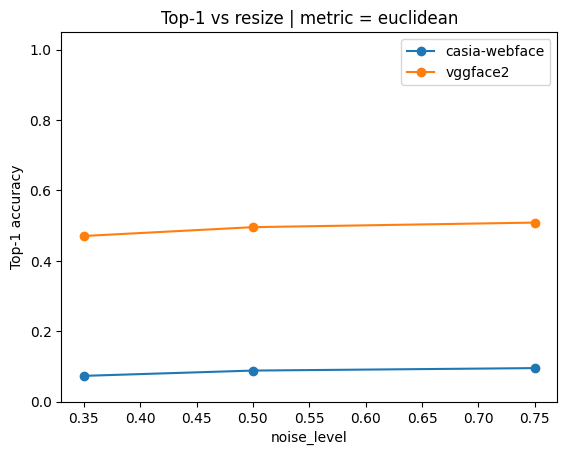

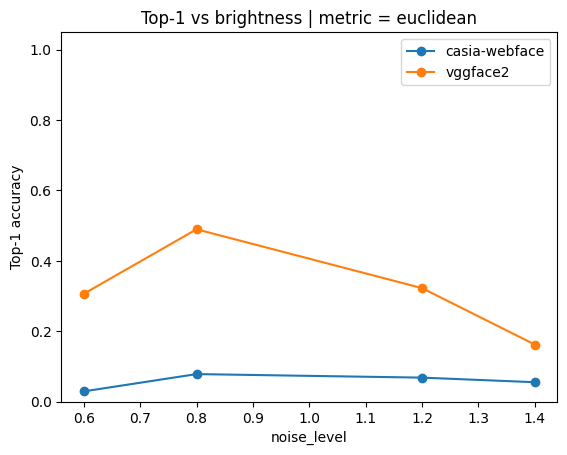

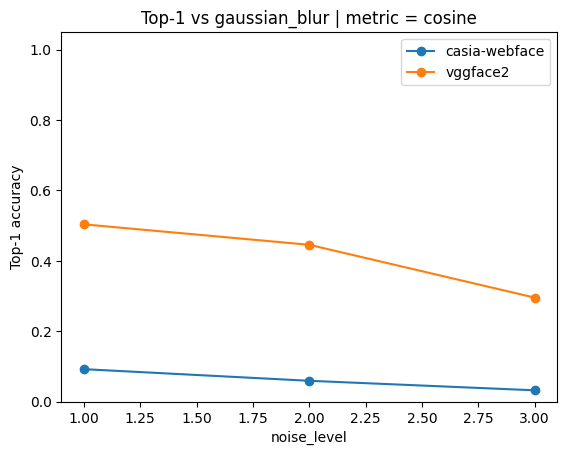

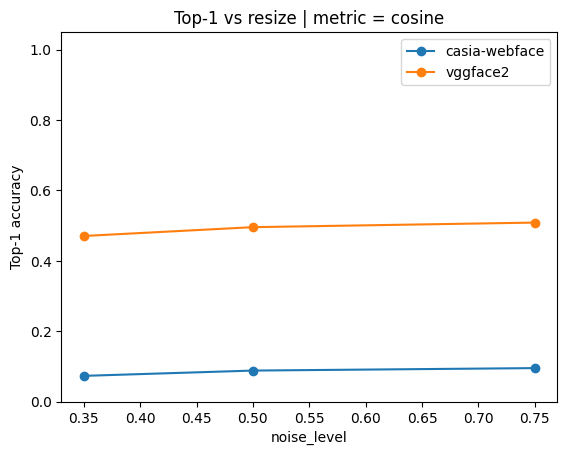

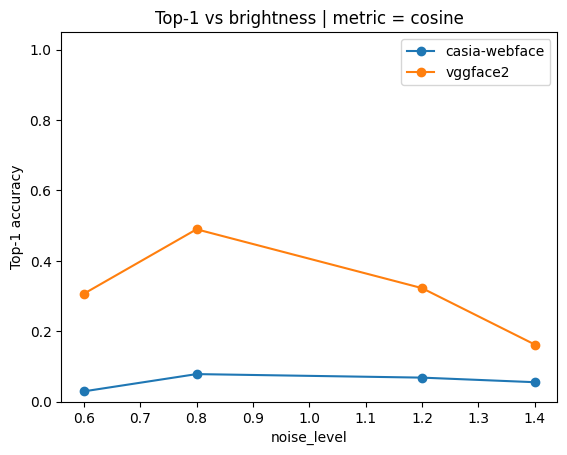

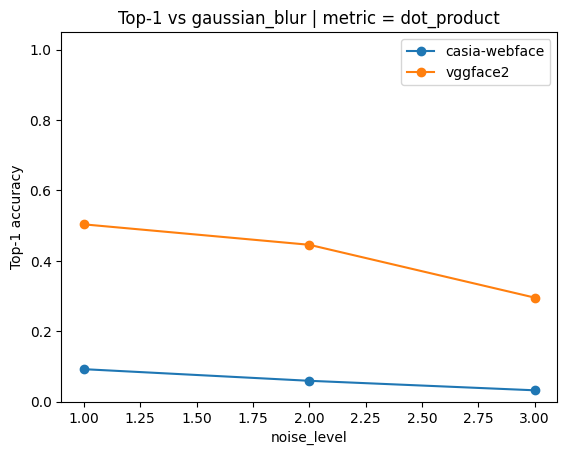

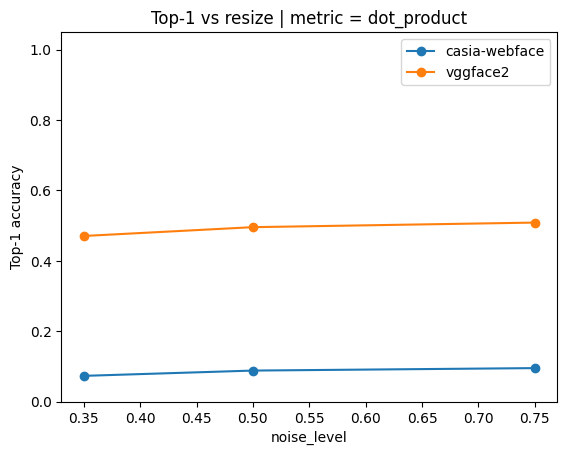

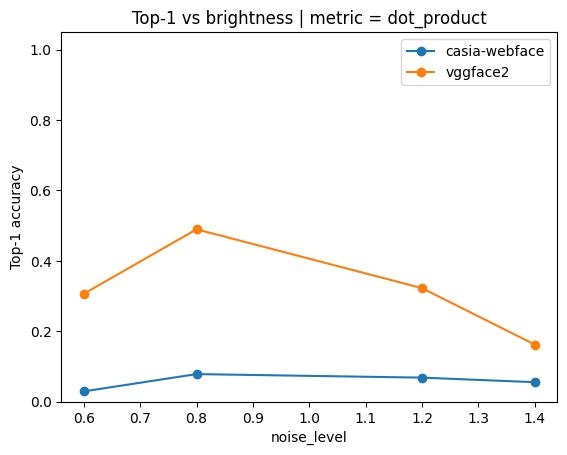

In [16]:
import matplotlib.pyplot as plt

def plot_noise_curve(metric: str, noise_type: str):
    sub = noisy_top1[(noisy_top1["metric"] == metric) & (noisy_top1["noise_type"] == noise_type)].sort_values("noise_level")
    plt.figure()
    for model_name in MODEL_NAMES:
        s = sub[sub["model"] == model_name]
        plt.plot(s["noise_level"], s["topk_accuracy"], marker="o", label=model_name)
    plt.xlabel("noise_level")
    plt.ylabel("Top-1 accuracy")
    plt.title(f"Top-1 vs {noise_type} | metric = {metric}")
    plt.legend()
    plt.ylim(0, 1.05)
    plt.show()

for metric in PRIMARY_METRICS:
    plot_noise_curve(metric, "gaussian_blur")
    plot_noise_curve(metric, "resize")
    plot_noise_curve(metric, "brightness")


## Final interpretation

The table below is the final Task 1 summary.


In [17]:
final_task1_summary = decision_table.copy()
final_task1_summary


,metric,model,top1,top3,top5,clean_top1,avg_noisy_top1,worst_noisy_top1,clean_mrr,avg_noisy_mrr,worst_noisy_mrr
0,cosine,vggface2,0.506507,0.619620,0.664665,0.506507,0.399900,0.162162,0.579554,0.475136,0.223738
1,cosine,casia-webface,0.093093,0.137137,0.163163,0.093093,0.066967,0.029029,0.133991,0.103487,0.058432
2,dot_product,vggface2,0.506507,0.619620,0.664665,0.506507,0.399900,0.162162,0.579554,0.475136,0.223738
3,dot_product,casia-webface,0.093093,0.137137,0.163163,0.093093,0.066967,0.029029,0.133991,0.103487,0.058432
4,euclidean,vggface2,0.506507,0.619620,0.664665,0.506507,0.399900,0.162162,0.579554,0.475136,0.223738
5,euclidean,casia-webface,0.093093,0.137137,0.163163,0.093093,0.066967,0.029029,0.133991,0.103487,0.058432


## Supplementary analysis: Minkowski distance

`FaissSearch` in the project also defines a `minkowski` metric, but unlike the primary metrics above, it is implemented through **candidate retrieval + reranking**, not as a native exact FAISS metric. Because this two-stage approach requires first retrieving a large candidate set and then recomputing distances over it, the MRR computation under Minkowski is very inefficient compared with the native metric, so we do not compute it.


In [18]:
# Supplementary Minkowski evaluation
# - keep clean Top-1 / Top-3 / Top-5
# - keep noisy Top-1 summary
# - DO NOT compute MRR for Minkowski

INCLUDE_MINKOWSKI_SUPPLEMENT = True

if INCLUDE_MINKOWSKI_SUPPLEMENT:
    mink_rows = []

    for model_name in MODEL_NAMES:
        # Clean Minkowski: Top-1 / Top-3 / Top-5
        mink_rows.append(
            evaluate_condition(
                model_name,
                "minkowski",
                "none",
                0.0,
                k_values=K_VALUES,
                minkowski_p=MINKOWSKI_P
            )
        )

        # Noisy Minkowski: Top-1 only
        for noise_type, noise_level in NOISE_PLAN:
            mink_rows.append(
                evaluate_condition(
                    model_name,
                    "minkowski",
                    noise_type,
                    noise_level,
                    k_values=(1,),
                    minkowski_p=MINKOWSKI_P
                )
            )

    mink_df = pd.concat(mink_rows, ignore_index=True)

    # 1) Clean Top-k summary
    mink_clean = (
        mink_df[mink_df["noise_type"] == "none"]
        .pivot_table(
            index=["metric", "model"],
            columns="k",
            values="topk_accuracy",
            aggfunc="mean"
        )
        .reset_index()
        .rename(columns={1: "clean_top1", 3: "clean_top3", 5: "clean_top5"})
    )

    # 2) Noisy Top-1 summary
    mink_top1 = mink_df[mink_df["k"] == 1].copy()
    mink_noisy = (
        mink_top1[mink_top1["noise_type"] != "none"]
        .groupby(["metric", "model"], as_index=False)
        .agg(
            avg_noisy_top1=("topk_accuracy", "mean"),
            worst_noisy_top1=("topk_accuracy", "min")
        )
    )

    # 3) Final Minkowski summary
    mink_summary_df = (
        mink_clean
        .merge(mink_noisy, on=["metric", "model"], how="left")
        .sort_values(["model"])
        .reset_index(drop=True)
    )

    display(mink_summary_df)

    # 4) Winner table restricted to Minkowski
    best = mink_summary_df.sort_values(
        ["clean_top1", "avg_noisy_top1", "worst_noisy_top1"],
        ascending=False
    ).iloc[0]

    mink_winner_df = pd.DataFrame([{
        "metric": "minkowski",
        "winner_model": best["model"],
        "clean_top1": best["clean_top1"],
        "clean_top3": best["clean_top3"],
        "clean_top5": best["clean_top5"],
        "avg_noisy_top1": best["avg_noisy_top1"],
        "worst_noisy_top1": best["worst_noisy_top1"],
    }])

    display(mink_winner_df)

    # 5) Optional combined summary table with the main exact metrics
    if "summary_df" in globals():
        summary_with_minkowski_df = pd.concat(
            [summary_df, mink_summary_df],
            ignore_index=True
        ).sort_values(["metric", "model"]).reset_index(drop=True)

        display(summary_with_minkowski_df)

else:
    print("INCLUDE_MINKOWSKI_SUPPLEMENT = False — supplementary Minkowski section skipped.")

,metric,model,clean_top1,clean_top3,clean_top5,avg_noisy_top1,worst_noisy_top1
0,minkowski,casia-webface,0.092092,0.138138,0.161161,0.067067,0.029029
1,minkowski,vggface2,0.507508,0.614615,0.664665,0.400200,0.160160


,metric,winner_model,clean_top1,clean_top3,clean_top5,avg_noisy_top1,worst_noisy_top1
0,minkowski,vggface2,0.507508,0.614615,0.664665,0.4002,0.16016


,metric,model,clean_top1,avg_noisy_top1,worst_noisy_top1,clean_mrr,avg_noisy_mrr,worst_noisy_mrr,clean_top3,clean_top5
0,cosine,casia-webface,0.093093,0.066967,0.029029,0.133991,0.103487,0.058432,NaN,NaN
1,cosine,vggface2,0.506507,0.399900,0.162162,0.579554,0.475136,0.223738,NaN,NaN
2,dot_product,casia-webface,0.093093,0.066967,0.029029,0.133991,0.103487,0.058432,NaN,NaN
3,dot_product,vggface2,0.506507,0.399900,0.162162,0.579554,0.475136,0.223738,NaN,NaN
4,euclidean,casia-webface,0.093093,0.066967,0.029029,0.133991,0.103487,0.058432,NaN,NaN
5,euclidean,vggface2,0.506507,0.399900,0.162162,0.579554,0.475136,0.223738,NaN,NaN
6,minkowski,casia-webface,0.092092,0.067067,0.029029,NaN,NaN,NaN,0.138138,0.161161
7,minkowski,vggface2,0.507508,0.400200,0.160160,NaN,NaN,NaN,0.614615,0.664665
